# **Egypt Real Estate Market Analysis**
**Goal:** understand pricing patterns in Egyptian real estate listings (price per sqm by city and type, payment terms, unusual prices).

**Data:** ~20,000 PropertyFinder Egypt listings (asking prices, mostly dated Aug-Sep 2025), from [Kaggle](https://www.kaggle.com/datasets/hassankhaled21/egyptian-real-estate-listings).

**Tools:** Python (pandas, matplotlib, seaborn). SQL and Power BI follow in separate folders.

# **Setup & Loading**

In [14]:
import pandas as pd
import numpy as np

# Load the raw data and keep an untouched copy
df_raw = pd.read_csv("/content/egypt_real_estate_listings.csv")
df = df_raw.copy()

print(df.shape)
df.head()

(19924, 11)


,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
0,https://www.propertyfinder.eg/en/plp/buy/chale...,"8,000,000",OWN A CHALET IN EL GOUNA WITH A PRIME LOCATION...,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Chalet,732 sqft / 68 sqm,1+ Maid,1,31 Aug 2025,Cash,"1,200,000 EGP"
1,https://www.propertyfinder.eg/en/plp/buy/villa...,"25,000,000","For sale, a villa with immediate delivery in C...","Karmell, New Zayed City, Sheikh Zayed City, Giza",Villa,"2,368 sqft / 220 sqm",4,4,2 Sep 2025,Cash,"2,100,000 EGP"
2,https://www.propertyfinder.eg/en/plp/buy/chale...,"15,135,000","With a down payment of EGP 1,513,000, a fully ...","Azha North, Ras Al Hekma, North Coast",Chalet,"1,270 sqft / 118 sqm",2,2,19 Aug 2025,Cash,"1,513,000 EGP"
3,https://www.propertyfinder.eg/en/plp/buy/apart...,"12,652,000",Own an apartment in New Cairo with a minimal d...,"Taj City, 5th Settlement Compounds, The 5th Se...",Apartment,"1,787 sqft / 166 sqm",3,2,26 Aug 2025,Installments,"1,260,000 EGP"
4,https://www.propertyfinder.eg/en/plp/buy/villa...,"45,250,000",Project: Granville\nLocation: Fifth Settlement...,"Granville, New Capital City, Cairo",Villa,"4,306 sqft / 400 sqm",7,7,2 Sep 2025,Cash,"2,262,500 EGP"


# **Initial Inspection**

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19924 entries, 0 to 19923
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   url             19924 non-null  object
 1   price           19385 non-null  object
 2   description     19846 non-null  object
 3   location        19833 non-null  object
 4   type            19847 non-null  object
 5   size            19847 non-null  object
 6   bedrooms        19780 non-null  object
 7   bathrooms       19784 non-null  object
 8   available_from  19261 non-null  object
 9   payment_method  19383 non-null  object
 10  down_payment    5445 non-null   object
dtypes: object(11)
memory usage: 1.7+ MB


In [16]:
df.isnull().sum()

,0
url,0
price,539
description,78
location,91
type,77
size,77
bedrooms,144
bathrooms,140
available_from,663
payment_method,541


# **Data Cleaning**

# 1.Numeric columns

In [17]:
# price: remove commas and convert to number
df["price"] = pd.to_numeric(df["price"].str.replace(",", "", regex=False), errors="coerce")
# down_payment: keep digits only (removes " EGP" and commas)
df["down_payment"] = pd.to_numeric(df["down_payment"].str.replace(r"[^\d]", "", regex=True), errors="coerce")
# size: extract the sqm value from text like "732 sqft / 68 sqm"
df["size_sqm"] = pd.to_numeric(
    df["size"].str.extract(r"/\s*([\d,]+)\s*sqm")[0].str.replace(",", "", regex=False),
    errors="coerce",
)

df[["price", "down_payment", "size_sqm"]].describe()

,price,down_payment,size_sqm
count,1.938500e+04,5.445000e+03,1.984700e+04
mean,1.641531e+07,1.981042e+06,1.034563e+03
std,2.369791e+07,3.868577e+06,1.122570e+05
min,1.869000e+05,1.000000e+00,1.000000e+00
25%,6.000000e+06,4.837500e+05,1.270000e+02
50%,1.034555e+07,9.430000e+05,1.700000e+02
75%,1.816900e+07,2.040000e+06,2.410000e+02
max,8.400000e+08,1.500000e+08,1.581169e+07


# 2. Location

In [18]:
# Split "Compound, ..., City, Region" into separate columns
parts = df["location"].str.split(",")

df["region"]   = parts.str[-1].str.strip()
df["city"]     = parts.apply(lambda x: x[-2].strip() if isinstance(x, list) and len(x) >= 2 else None)
df["compound"] = parts.apply(lambda x: x[0].strip() if isinstance(x, list) and len(x) >= 3 else None)

df[["location", "compound", "city", "region"]].head()

,location,compound,city,region
0,"Swan Lake Gouna, Al Gouna, Hurghada, Red Sea",Swan Lake Gouna,Hurghada,Red Sea
1,"Karmell, New Zayed City, Sheikh Zayed City, Giza",Karmell,Sheikh Zayed City,Giza
2,"Azha North, Ras Al Hekma, North Coast",Azha North,Ras Al Hekma,North Coast
3,"Taj City, 5th Settlement Compounds, The 5th Se...",Taj City,New Cairo City,Cairo
4,"Granville, New Capital City, Cairo",Granville,New Capital City,Cairo


In [19]:
print(df[["compound", "city", "region"]].nunique())
print(df["region"].value_counts().head(6))
print(df["city"].value_counts().head(10))

compound    1433
city          70
region        16
dtype: int64
region
Cairo          7610
North Coast    5246
Giza           4276
Red Sea        1598
Suez            601
Alexandria      385
Name: count, dtype: int64
city
New Cairo City                  5219
6 October City                  2173
Sheikh Zayed City               1910
Ras Al Hekma                    1793
Hurghada                        1597
Sidi Abdel Rahman               1056
Qesm Marsa Matrouh               968
Mostakbal City - Future City     671
Qesm Ad Dabaah                   659
Al Ain Al Sokhna                 601
Name: count, dtype: int64


# 3. Bedrooms and bathrooms

In [20]:
# bedrooms: split into a number and a "has maid room" flag
b = df["bedrooms"].str.lower()

df["has_maid_room"] = b.str.contains("maid").where(b.notna())
df["bedrooms_num"] = pd.to_numeric(b.str.extract(r"(\d+)")[0], errors="coerce")
df.loc[b.str.contains("studio", na=False), "bedrooms_num"] = 0   # studio = 0 bedrooms

# bathrooms: keep the number only ("7+" -> 7, "2.0" -> 2, "none" -> missing)
df["bathrooms_num"] = pd.to_numeric(df["bathrooms"].str.extract(r"(\d+)")[0], errors="coerce")

In [21]:
print(df["bedrooms_num"].value_counts(dropna=False).sort_index())
print(df["bathrooms_num"].value_counts(dropna=False).sort_index())
print(df["has_maid_room"].value_counts(dropna=False))

bedrooms_num
0.0     328
1.0    1198
2.0    4597
3.0    8696
4.0    3252
5.0    1111
6.0     347
7.0     251
NaN     144
Name: count, dtype: int64
bathrooms_num
1.0    2118
2.0    5577
3.0    6610
4.0    3300
5.0    1324
6.0     466
7.0     384
NaN     145
Name: count, dtype: int64
has_maid_room
False    10439
True      9341
NaN        144
Name: count, dtype: int64


# 4. Blank rows, duplicates, and property type

In [22]:
# Original columns, without url (to detect blank and repeated listings)
raw_cols = [c for c in df_raw.columns if c != "url"]
rows_before = len(df)

In [23]:
# 1. Remove blank listings (only a url, everything else empty)
blank = df[raw_cols].isnull().all(axis=1)
df = df[~blank].copy()
print("Blank rows removed:", blank.sum())


Blank rows removed: 77


In [24]:
# 2. Remove duplicates (identical in every column except url)
dup = df.duplicated(subset=raw_cols)
df = df[~dup].copy()
print("Duplicate rows removed:", dup.sum())

Duplicate rows removed: 95


In [25]:
# 3. Group rare property types into "Other"
rare_types = ["Land", "Cabin", "Palace", "Whole Building",
              "Roof", "Full Floor", "Bulk Sale Unit", "Bungalow"]
df["type"] = df["type"].replace(rare_types, "Other")

print("Rows before:", rows_before, "| after:", len(df))
df["type"].value_counts()

Rows before: 19924 | after: 19752


,count
type,
Apartment,8339
Chalet,3995
Villa,3559
Townhouse,1330
Twin House,831
Duplex,621
Penthouse,568
iVilla,267
Other,138


# 5. Price per sqm and outliers

In [26]:
# Price per square meter
df["price_per_sqm"] = df["price"] / df["size_sqm"]

In [27]:
# Rule 1: impossible sizes (e.g. 1 sqm chalet, 15 million sqm apartment)
bad_size = (df["size_sqm"] < 20) | (df["size_sqm"] > 5000)

In [28]:
# Rule 2: extreme price per sqm within each property type (3 x IQR, log scale)
log_pps = np.log10(df["price_per_sqm"].where(~bad_size))
grp = log_pps.groupby(df["type"])
q1 = grp.transform(lambda s: s.quantile(0.25))
q3 = grp.transform(lambda s: s.quantile(0.75))
iqr = q3 - q1
extreme_pps = (log_pps < q1 - 3 * iqr) | (log_pps > q3 + 3 * iqr)

In [29]:
# Flag them (rows are kept, not deleted)
df["is_outlier"] = bad_size | extreme_pps
df["outlier_reason"] = np.select(
    [bad_size, extreme_pps],
    ["invalid size", "extreme price per sqm"],
    default="",
)

print(df.shape)
print(df["outlier_reason"].value_counts())

(19752, 21)
outlier_reason
                         19705
extreme price per sqm       37
invalid size                10
Name: count, dtype: int64


In [30]:
# Review: lowest and highest price per sqm (look at them yourself)
cols = ["type", "city", "price", "size_sqm", "price_per_sqm", "is_outlier"]
print(df.sort_values("price_per_sqm").head(15)[cols])
print(df.sort_values("price_per_sqm", ascending=False).head(15)[cols])

             type                          city       price    size_sqm  \
4410    Apartment  Mostakbal City - Future City  11692311.0  15811692.0   
15510      Chalet                  Ras Al Hekma   6550000.0     96106.0   
8174    Apartment                     Hay Sharq   3500000.0      6779.0   
15671   Apartment             Sheikh Zayed City    186900.0       178.0   
19737       Other                6 October City   1500000.0      1150.0   
13470       Villa                  New Mansoura    815000.0       623.0   
3538    Apartment                6 October City    202500.0       153.0   
17228       Other                6 October City    800000.0       600.0   
14082       Other                6 October City    800000.0       600.0   
18599       Other                6 October City    800000.0       600.0   
454     Apartment                6 October City    200000.0       150.0   
16617       Other                6 October City   3300000.0      2450.0   
7507    Apartment        

In [31]:
clean = df[~df["is_outlier"]]
clean["price_per_sqm"].describe()

,price_per_sqm
count,1.924800e+04
mean,7.550985e+04
std,5.414004e+04
min,1.304348e+03
25%,3.949679e+04
50%,6.378844e+04
75%,9.690519e+04
max,1.363636e+06


# 6. Final fixes: outliers, down payment, dates

In [32]:
# Rule 3: price per sqm above 1,000,000 EGP (e.g. a 44 sqm villa listed at 60M)
manual = df["price_per_sqm"] > 1_000_000
df.loc[manual & ~df["is_outlier"], "outlier_reason"] = "price per sqm above 1M"
df.loc[manual, "is_outlier"] = True

In [33]:
# down_payment: values under 1,000 are percentages typed as EGP ("5 EGP" = "5% down") -> missing
tiny_dp = df["down_payment"] < 1000
df.loc[tiny_dp, "down_payment"] = np.nan
df["down_payment_pct"] = (df["down_payment"] / df["price"] * 100).round(2)

In [34]:
# available_from: text -> date
df["available_from"] = pd.to_datetime(df["available_from"], format="%d %b %Y", errors="coerce")

In [35]:
print("Outliers:", df["is_outlier"].sum())
print(df["outlier_reason"].value_counts())
print("Listings with down payment:", df["down_payment"].notna().sum())
df["down_payment_pct"].describe()

Outliers: 48
outlier_reason
                          19704
extreme price per sqm        37
invalid size                 10
price per sqm above 1M        1
Name: count, dtype: int64
Listings with down payment: 5072


,down_payment_pct
count,5072.000000
mean,15.204338
std,13.698420
min,0.010000
25%,5.000000
50%,10.000000
75%,22.652500
max,50.000000


# 7. Save cleaned data

In [36]:
df = df.reset_index(drop=True)
df.insert(0, "listing_id", range(1, len(df) + 1))

final_cols = ["listing_id", "type", "price", "size_sqm", "price_per_sqm",
              "bedrooms_num", "bathrooms_num", "has_maid_room",
              "compound", "city", "region", "payment_method",
              "down_payment", "down_payment_pct", "available_from",
              "is_outlier", "outlier_reason"]

cleaned = df[final_cols]
cleaned.to_csv("cleaned_data.csv", index=False)

print(cleaned.shape)
cleaned.head()

(19752, 17)


,listing_id,type,price,size_sqm,price_per_sqm,bedrooms_num,bathrooms_num,has_maid_room,compound,city,region,payment_method,down_payment,down_payment_pct,available_from,is_outlier,outlier_reason
0,1,Chalet,8000000.0,68.0,117647.058824,1.0,1.0,True,Swan Lake Gouna,Hurghada,Red Sea,Cash,1200000.0,15.00,2025-08-31,False,
1,2,Villa,25000000.0,220.0,113636.363636,4.0,4.0,False,Karmell,Sheikh Zayed City,Giza,Cash,2100000.0,8.40,2025-09-02,False,
2,3,Chalet,15135000.0,118.0,128262.711864,2.0,2.0,False,Azha North,Ras Al Hekma,North Coast,Cash,1513000.0,10.00,2025-08-19,False,
3,4,Apartment,12652000.0,166.0,76216.867470,3.0,2.0,False,Taj City,New Cairo City,Cairo,Installments,1260000.0,9.96,2025-08-26,False,
4,5,Villa,45250000.0,400.0,113125.000000,7.0,7.0,False,Granville,New Capital City,Cairo,Cash,2262500.0,5.00,2025-09-02,False,


# **EDA**

# Analysis dataset

In [37]:
import matplotlib.pyplot as plt

# Exclude flagged outliers and listings without a price per sqm
analysis = df[(~df["is_outlier"]) & (df["price_per_sqm"].notna())]

# Residential units vs. chalets (analyzed separately, as planned in questions.md)
resi_types = ["Apartment", "Villa", "Townhouse", "Twin House", "Duplex", "Penthouse", "iVilla"]
resi = analysis[analysis["type"].isin(resi_types)]
chalets = analysis[analysis["type"] == "Chalet"]

print("Analysis rows:", len(analysis))
print("Residential:", len(resi), "| Chalets:", len(chalets))

Analysis rows: 19247
Residential: 15096 | Chalets: 3918


# **Q1 & Q6: Price per sqm by city**

In [38]:
city_stats = (
    resi.groupby("city")["price_per_sqm"]
    .agg(listings="count", median="median", mean="mean")
    .round(0)
    .query("listings >= 30")
    .sort_values("median", ascending=False)
)

print("Cities with 30+ listings:", len(city_stats))
display(city_stats.head(10))
display(city_stats.tail(10))

Cities with 30+ listings: 31


,listings,median,mean
city,,,
Sidi Abdel Rahman,379,130769.0,141846.0
Qesm Marsa Matrouh,430,116667.0,132482.0
Qesm Ad Dabaah,312,110756.0,129186.0
Sidi Heneish,51,107143.0,119086.0
Ras Al Hekma,590,102848.0,111614.0
Mokattam,132,100459.0,106610.0
Hurghada,1061,77778.0,96950.0
New Heliopolis,190,70645.0,74960.0
Al Ain Al Sokhna,129,70000.0,66809.0


,listings,median,mean
city,,,
Dokki,38,35679.0,39432.0
Hay Sharq,230,34278.0,36959.0
Mohandessin,39,33636.0,33309.0
Hay El Maadi,96,32440.0,46378.0
Nasr City,57,27143.0,28659.0
Obour City,50,23261.0,23678.0
Hay Awal El Montazah,37,21739.0,28111.0
Hadayek El Ahram,52,15963.0,15771.0
Hay El Haram,33,10556.0,11777.0


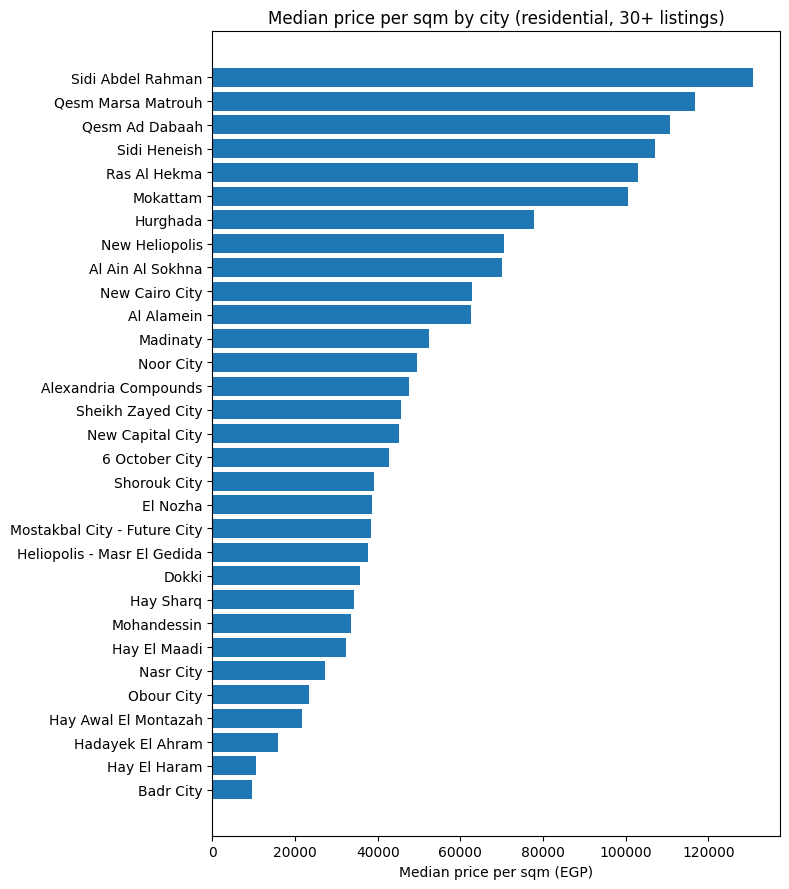

In [39]:
s = city_stats["median"].sort_values()

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(s.index, s.values)
ax.set_xlabel("Median price per sqm (EGP)")
ax.set_title("Median price per sqm by city (residential, 30+ listings)")
plt.tight_layout()
plt.show()

In [40]:
region_stats = (
    resi.groupby("region")["price_per_sqm"]
    .agg(listings="count", median="median")
    .round(0)
    .query("listings >= 30")
    .sort_values("median", ascending=False)
)
region_stats

,listings,median
region,,
North Coast,2036,104167.0
Red Sea,1062,77761.0
Suez,129,70000.0
Cairo,7352,57149.0
Giza,4053,42405.0
Alexandria,381,35862.0
Qalyubia,54,23261.0


# **Q1 & Q6 insight**
Median price per sqm varies widely across cities, from about 9.7K EGP in Badr City to about 130.8K EGP in Sidi Abdel Rahman. By region, the North Coast has the highest median (104.2K), followed by the Red Sea (77.8K) and Cairo (57.1K); Giza (42.4K) and Alexandria (35.9K) are lower. New Cairo, the largest market (5,086 residential listings), sits at 62.8K. Coastal figures include vacation homes, so they are not directly comparable with year-round residential areas.

# **Q2: Apartments vs. villas in the same city**

In [41]:
av = resi[resi["type"].isin(["Apartment", "Villa"])]

# Keep cities with at least 30 apartments AND 30 villas
counts = av.pivot_table(index="city", columns="type", values="price_per_sqm", aggfunc="count").fillna(0)
cities = counts[(counts["Apartment"] >= 30) & (counts["Villa"] >= 30)].index
print("Cities with 30+ apartments and 30+ villas:", len(cities))

# Median price per sqm by city and type
compare = (
    av[av["city"].isin(cities)]
    .groupby(["city", "type"])["price_per_sqm"]
    .median()
    .unstack()
    .round(0)
)
compare["villa_premium_%"] = ((compare["Villa"] / compare["Apartment"] - 1) * 100).round(0)
compare = compare.sort_values("villa_premium_%")
compare

Cities with 30+ apartments and 30+ villas: 11


type,Apartment,Villa,villa_premium_%
city,,,
New Heliopolis,71721.0,73857.0,3.0
6 October City,38661.0,47160.0,22.0
Sheikh Zayed City,39900.0,55636.0,39.0
Al Alamein,53852.0,76000.0,41.0
Mostakbal City - Future City,34864.0,50209.0,44.0
Shorouk City,33771.0,51220.0,52.0
Mokattam,84000.0,128571.0,53.0
New Capital City,40840.0,65395.0,60.0
Hurghada,61741.0,100625.0,63.0


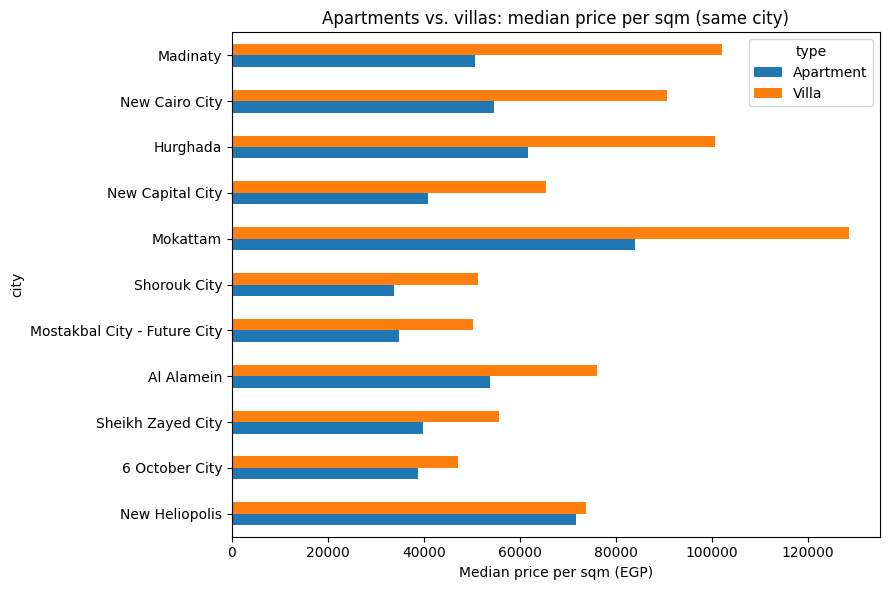

In [42]:
compare[["Apartment", "Villa"]].plot(kind="barh", figsize=(9, 6))
plt.xlabel("Median price per sqm (EGP)")
plt.title("Apartments vs. villas: median price per sqm (same city)")
plt.tight_layout()
plt.show()

In [43]:
av.groupby("type")[["price_per_sqm", "price", "size_sqm"]].median().round(0)

,price_per_sqm,price,size_sqm
type,,,
Apartment,46875.0,6750000.0,155.0
Villa,83333.0,28000000.0,321.0


# **Q2 insight**
In all 11 cities with at least 30 apartments and 30 villas, villas cost more per sqm than apartments, by 3% (New Heliopolis) to 102% (Madinaty). Overall, the median villa is about twice the size of the median apartment (321 vs. 155 sqm) and costs 28M vs. 6.75M EGP in total. This shows association, not cause: the data has no land, finishing, or compound details.

# **Q3: Cash vs. Installments (price)**

In [44]:
import seaborn as sns

pm = resi[resi["payment_method"].notna()].copy()

# 1. Raw comparison
raw = pm.groupby("payment_method")["price_per_sqm"].agg(listings="count", median="median").round(0)
display(raw)

# 2. Fair comparison: each listing vs. the typical listing of the same type in the same city
pm["group_median"] = pm.groupby(["city", "type"])["price_per_sqm"].transform("median")
pm["group_size"] = pm.groupby(["city", "type"])["price_per_sqm"].transform("count")
pm["relative_price"] = pm["price_per_sqm"] / pm["group_median"]

fair_df = pm[pm["group_size"] >= 30]
fair = fair_df.groupby("payment_method")["relative_price"].agg(listings="count", median="median").round(3)
display(fair)

,listings,median
payment_method,,
Cash,12383,55000.0
Installments,2712,72702.0


,listings,median
payment_method,,
Cash,11738,0.970
Installments,2566,1.228


# **Q3 insight**
Installment listings are priced higher per sqm: median 72.7K vs. 55.0K for cash listings (+32%). After comparing each listing with the typical listing of the same type in the same city, installment listings sit about 23% above typical and cash listings about 3% below. The distributions overlap heavily, so this is a tendency, not a rule. Many "Cash" listings also mention payment plans, so the label is not a reliable indicator of how a buyer would pay.

# **Q8: Down payment by payment method**

In [45]:
dp = resi[resi["down_payment_pct"].notna() & resi["payment_method"].notna()]

# Down payment % by payment method
display(dp.groupby("payment_method")["down_payment_pct"].describe().round(1))

# How often is a down payment reported?
resi.groupby("payment_method")["down_payment_pct"].apply(lambda s: s.notna().mean()).round(3)

,count,mean,std,min,25%,50%,75%,max
payment_method,,,,,,,,
Cash,1741.0,16.4,14.1,0.1,5.0,10.0,25.0,50.0
Installments,1851.0,17.2,14.6,0.1,5.0,10.0,28.6,50.0


,down_payment_pct
payment_method,
Cash,0.141
Installments,0.683


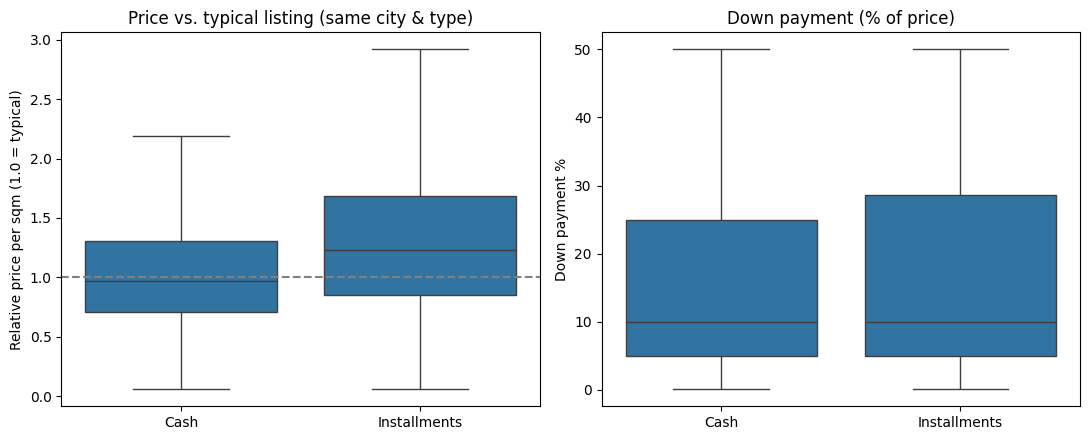

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.boxplot(data=fair_df, x="payment_method", y="relative_price", showfliers=False, ax=axes[0])
axes[0].axhline(1, color="gray", linestyle="--")
axes[0].set_title("Price vs. typical listing (same city & type)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Relative price per sqm (1.0 = typical)")

sns.boxplot(data=dp, x="payment_method", y="down_payment_pct", showfliers=False, ax=axes[1])
axes[1].set_title("Down payment (% of price)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Down payment %")

plt.tight_layout()
plt.show()

# **Q8 insight**
Installment listings do not show lower down payments: the median is 10% in both groups (mean 17.2% vs. 16.4%). A down payment is reported for 68% of installment listings but only 14% of cash listings, and 1,741 residential "Cash" listings still report one, which supports the label caveat above.

# **Q7: Price per sqm by unit size**

In [47]:
resi = resi.copy()

# Size bands
bins = [0, 100, 150, 200, 300, 500, 5000]
labels = ["<100", "100-149", "150-199", "200-299", "300-499", "500+"]
resi["size_band"] = pd.cut(resi["size_sqm"], bins=bins, labels=labels, right=False)

# 1. All residential units
overall = resi.groupby("size_band", observed=True)["price_per_sqm"].agg(listings="count", median="median").round(0)
display(overall)

,listings,median
size_band,,
<100,1145,58800.0
100-149,2935,53906.0
150-199,4174,48758.0
200-299,4064,60129.0
300-499,2008,75000.0
500+,770,76119.0


In [48]:
# 2. Apartments and villas separately (hide cells with fewer than 30 listings)
sub = resi[resi["type"].isin(["Apartment", "Villa"])]
med = sub.pivot_table(index="size_band", columns="type", values="price_per_sqm", aggfunc="median", observed=True)
cnt = sub.pivot_table(index="size_band", columns="type", values="price_per_sqm", aggfunc="count", observed=True)
med = med.where(cnt >= 30).round(0)
display(med)

type,Apartment,Villa
size_band,,
<100,56121.0,NaN
100-149,50081.0,155738.0
150-199,42169.0,96825.0
200-299,42000.0,81683.0
300-499,38296.0,82230.0
500+,NaN,78824.0


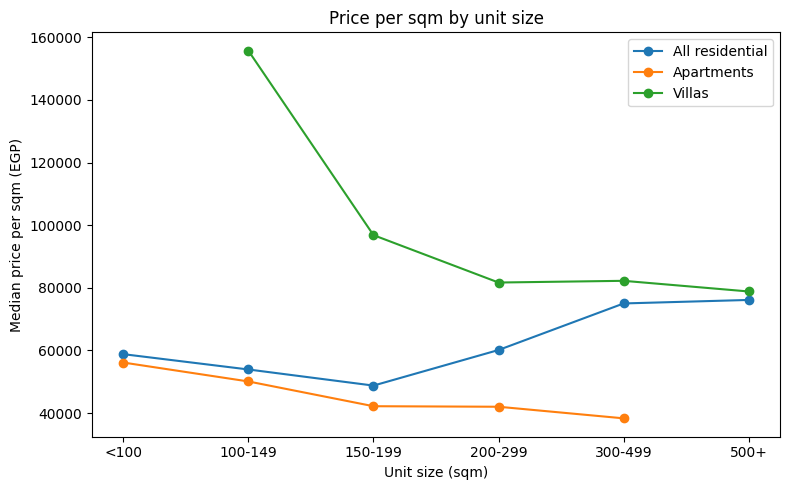

In [49]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(overall.index.astype(str), overall["median"], marker="o", label="All residential")
ax.plot(med.index.astype(str), med["Apartment"], marker="o", label="Apartments")
ax.plot(med.index.astype(str), med["Villa"], marker="o", label="Villas")
ax.set_xlabel("Unit size (sqm)")
ax.set_ylabel("Median price per sqm (EGP)")
ax.set_title("Price per sqm by unit size")
ax.legend()
plt.tight_layout()
plt.show()

In [50]:
resi["group_median"] = resi.groupby(["city", "type"])["price_per_sqm"].transform("median")
resi["group_size"] = resi.groupby(["city", "type"])["price_per_sqm"].transform("count")
resi["relative_price"] = resi["price_per_sqm"] / resi["group_median"]

fair_size = resi[resi["group_size"] >= 30].groupby("size_band", observed=True)["relative_price"].agg(listings="count", median="median").round(3)
fair_size

,listings,median
size_band,,
<100,1078,1.070
100-149,2811,1.082
150-199,3987,0.963
200-299,3783,0.987
300-499,1897,0.974
500+,749,0.883


# **Q7 insight**
Overall, price per sqm rises for larger units, but this is a mix effect: units above 300 sqm are mostly villas, which cost more per sqm. Within each type, larger units are cheaper per sqm: apartments fall from 56.1K (under 100 sqm) to 38.3K (300-499 sqm), and villas from 155.7K (100-149 sqm) to 78.8K (500+ sqm). Controlling for city and type, relative price falls from about 1.07 to 0.88 across size bands.

# **Q4: Typical down payment by city**

In [51]:
dp = resi[resi["down_payment_pct"].notna()]

dp_city = (
    dp.groupby("city")["down_payment_pct"]
    .agg(listings="count", median="median", mean="mean")
    .round(1)
    .query("listings >= 30")
    .sort_values("median", ascending=False)
)

print(len(dp), "listings with a reported down payment")
display(dp_city)
dp["down_payment_pct"].describe().round(1)

3592 listings with a reported down payment


,listings,median,mean
city,,,
Noor City,30,30.3,30.0
Madinaty,53,29.5,30.3
Shorouk City,71,26.0,27.2
Alexandria Compounds,32,16.4,20.0
Hurghada,602,15.0,17.6
Obour City,31,14.9,14.2
New Cairo City,847,12.4,19.4
6 October City,339,10.0,16.9
New Capital City,128,10.0,11.3


,down_payment_pct
count,3592.0
mean,16.8
std,14.3
min,0.1
25%,5.0
50%,10.0
75%,27.2
max,50.0


# **Q4 insight**
The typical advertised down payment is 10% (median; mean 16.8%) across the 3,592 residential listings that report it. It is highest in Noor City, Madinaty, and Shorouk City (26-30%) and lowest on the North Coast and in New Heliopolis (5%). Most values are round numbers, with 5% the most common. Only about 26% of listings report a down payment, so these figures describe advertised terms, not actual deals.

# **Q5: Unusually priced listings (vs. their city and type)**

In [52]:
# Typical price per sqm for each city + type
resi["group_median"] = resi.groupby(["city", "type"])["price_per_sqm"].transform("median")
resi["group_size"] = resi.groupby(["city", "type"])["price_per_sqm"].transform("count")
resi["relative_price"] = resi["price_per_sqm"] / resi["group_median"]

cmp_df = resi[resi["group_size"] >= 30].copy()

# Flag listings outside 1.5 x IQR (log scale) of their own city + type group
log_pps = np.log10(cmp_df["price_per_sqm"])
grp = log_pps.groupby([cmp_df["city"], cmp_df["type"]])
q1 = grp.transform(lambda s: s.quantile(0.25))
q3 = grp.transform(lambda s: s.quantile(0.75))
iqr = q3 - q1

cmp_df["price_flag"] = np.select(
    [log_pps > q3 + 1.5 * iqr, log_pps < q1 - 1.5 * iqr],
    ["unusually high", "unusually low"],
    default="typical",
)

print(len(cmp_df), "listings compared")
print(cmp_df["price_flag"].value_counts())

14305 listings compared
price_flag
typical           14013
unusually low       207
unusually high       85
Name: count, dtype: int64


In [53]:
cols = ["city", "type", "price", "size_sqm", "price_per_sqm", "group_median", "relative_price"]

print("Most unusually HIGH")
display(cmp_df[cmp_df["price_flag"] == "unusually high"].sort_values("relative_price", ascending=False)[cols].head(10).round(1))

print("Most unusually LOW")
display(cmp_df[cmp_df["price_flag"] == "unusually low"].sort_values("relative_price")[cols].head(10).round(1))

Most unusually HIGH


,city,type,price,size_sqm,price_per_sqm,group_median,relative_price
12827,New Cairo City,Apartment,93500000.0,160.0,584375.0,54658.4,10.7
16349,Hurghada,Apartment,55000000.0,93.0,591397.8,61740.7,9.6
395,Qesm Marsa Matrouh,Villa,280000000.0,345.0,811594.2,122053.7,6.6
827,Hay El Maadi,Apartment,90000000.0,430.0,209302.3,32154.4,6.5
5799,Sheikh Zayed City,Apartment,51054840.0,200.0,255274.2,39900.0,6.4
1531,Hay El Maadi,Apartment,16700000.0,82.0,203658.5,32154.4,6.3
4966,Sheikh Zayed City,Apartment,49754520.0,200.0,248772.6,39900.0,6.2
2820,Ras Al Hekma,Villa,200500000.0,296.0,677364.9,111111.1,6.1
6292,Hay El Maadi,Apartment,80481000.0,430.0,187165.1,32154.4,5.8
9519,Hay El Maadi,Apartment,11400000.0,63.0,180952.4,32154.4,5.6


Most unusually LOW


,city,type,price,size_sqm,price_per_sqm,group_median,relative_price
5552,Sheikh Zayed City,Duplex,800000.0,270.0,2963.0,51250.0,0.1
13705,Ras Al Hekma,Villa,1200000.0,175.0,6857.1,111111.1,0.1
118,Hurghada,Villa,950000.0,140.0,6785.7,100625.0,0.1
190,Sheikh Zayed City,Apartment,325000.0,100.0,3250.0,39900.0,0.1
2603,Sheikh Zayed City,Apartment,325000.0,100.0,3250.0,39900.0,0.1
132,Sheikh Zayed City,Apartment,325000.0,100.0,3250.0,39900.0,0.1
5779,Sheikh Zayed City,Villa,2000000.0,431.0,4640.4,55636.4,0.1
4524,6 October City,Apartment,325000.0,100.0,3250.0,38660.7,0.1
438,6 October City,Apartment,325000.0,100.0,3250.0,38660.7,0.1
7815,New Cairo City,Apartment,600000.0,130.0,4615.4,54658.4,0.1


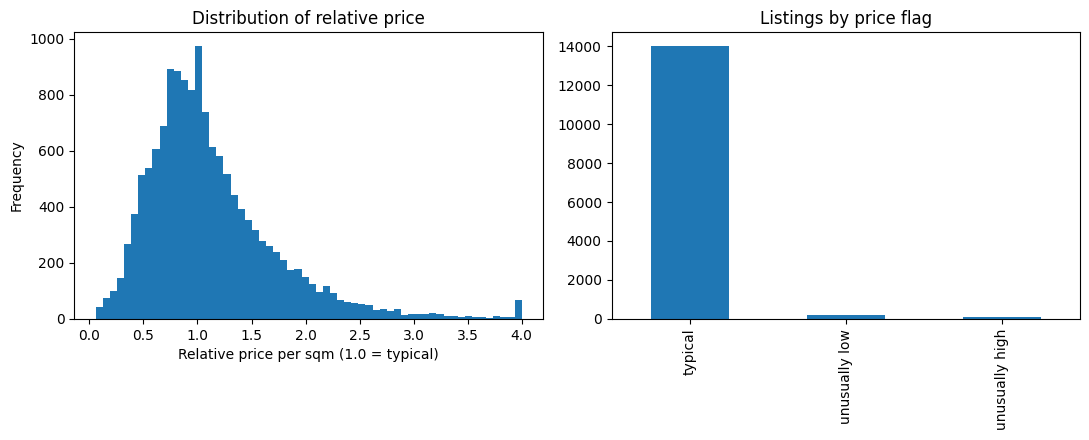

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cmp_df["relative_price"].clip(upper=4).plot(kind="hist", bins=60, ax=axes[0])
axes[0].set_xlabel("Relative price per sqm (1.0 = typical)")
axes[0].set_title("Distribution of relative price")

cmp_df["price_flag"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Listings by price flag")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

In [55]:
cs = cmp_df.groupby("city").agg(
    listings=("price_flag", "size"),
    flagged_share=("price_flag", lambda s: (s != "typical").mean()),
).round(3)
cs[cs["listings"] >= 200].sort_values("flagged_share", ascending=False).head(6)

,listings,flagged_share
city,,
Madinaty,341,0.100
Sidi Abdel Rahman,333,0.060
Ras Al Hekma,536,0.035
Al Alamein,230,0.030
New Capital City,255,0.024
Hay Sharq,223,0.022


# **Q5 insight**
Only 292 of 14,305 compared listings (2.0%) are priced unusually for their city and type: 207 unusually low and 85 unusually high. The low ones sit at a median of about 0.23x the typical price per sqm and are likely data errors or partial prices (for example, three identical 100 sqm apartments at 325K EGP in Sheikh Zayed). The high ones average about 3.7x typical and may be luxury units, inflated asking prices, or size errors; the data cannot tell which. Madinaty (10%) and Sidi Abdel Rahman (6%) have the highest share of unusual listings.


# **Chalets**

In [57]:
chalet_stats = (
    chalets.groupby("city")["price_per_sqm"]
    .agg(listings="count", median="median")
    .round(0)
    .query("listings >= 30")
    .sort_values("median", ascending=False)
)
display(chalet_stats)

print("Median price per sqm | chalets:", round(chalets["price_per_sqm"].median()),
      "| residential:", round(resi["price_per_sqm"].median()))

,listings,median
city,,
Hurghada,486,104708.0
Qesm Marsa Matrouh,475,104651.0
Qesm Ad Dabaah,320,103452.0
Sidi Abdel Rahman,613,100000.0
Sidi Heneish,44,100000.0
Ras Al Hekma,1138,91752.0
Al Ain Al Sokhna,429,51587.0
Al Alamein,299,50000.0


Median price per sqm | chalets: 86816 | residential: 58214


# **Chalets insight**
Chalets (3,918 listings, mostly on the North Coast and Red Sea) have a median price per sqm of 86.8K EGP, about 49% above residential units (58.2K).

# **Summary and limitations**
**Takeaways**
1. Price per sqm differs sharply by location: North Coast cities lead (about 103-131K EGP per sqm), while inland cities such as Badr City, Hay El Haram, and Hadayek El Ahram are far lower (under 16K).
2. Villas cost more per sqm than apartments in every city compared, and larger units are cheaper per sqm within each type.
3. Installment-labelled listings are priced higher, but their down payments match "Cash" listings (median 10%).
4. About 2% of listings are priced unusually for their city and type; most of the low ones look like data errors.
5. Chalets (20% of listings, mostly coastal) have a median price per sqm about 49% above residential units.

**Limitations**
- Asking prices, not sale prices; most listings are dated Aug-Sep 2025.
- City is the benchmark level; compound-level differences are not controlled.
- The Cash/Installments label is unreliable (many "Cash" listings mention payment plans).
- Down payment is reported in only ~26% of listings.
- Outlier thresholds (size, IQR, price per sqm cap) are judgment calls.
- "Other" types and Hotel Apartments are excluded from price analysis.
- Chalets are analyzed only at city level.